# Wyjaśnialność modeli w uczeniu maszynowym, semestr 2026L

## Lab 02 - Wprowadzenie do wyjaśnialności modeli AI (XAI)

# 1. Dlaczego dobre podstawy ML są ważne dla XAI

Zanim zaczniemy stosować metody wyjaśniania modeli, musimy upewnić się, że model został poprawnie zbudowany. W przeciwnym razie wyjaśnienia mogą być mylące.

Istnieje kilka typowych problemów:

* **data leakage** – model korzysta z informacji, które nie powinny być dostępne podczas predykcji
* **overfitting** – model zapamiętuje dane treningowe
* **niestabilne modele** – drobna zmiana danych powoduje duże zmiany w predykcjach

Jeśli model jest źle zbudowany, metody XAI mogą dawać wyjaśnienia, które wyglądają sensownie, ale nie mają wartości.

Dlatego w praktyce XAI zaczyna się od **dobrego pipeline ML**.

---

# 2. Dane do ćwiczeń

W ćwiczeniach użyjemy datasetu medycznego ze scikit-learn:

**Breast Cancer Dataset**

Model ma przewidywać:

```
czy guz jest złośliwy
```

Dataset zawiera m.in.:

* cechy geometryczne guza
* teksturę
* promień
* symetrię

---

# 3. Import bibliotek

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

# 4. Wczytanie danych

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Sprawdźmy wymiary danych.

In [3]:
X.shape

(569, 30)

Dataset zawiera około:

* 569 obserwacji
* 30 cech

---

# 5. Podział danych

Pierwszym krokiem w budowie modelu jest podział danych na:

* **zbiór treningowy**
* **zbiór testowy**

Dlaczego to ważne?

Jeśli model będzie oceniany na danych, na których był trenowany, wyniki będą **zawyżone**.

Opcja `stratify = y` pozwoli nam podzielić nam obserwacje, aby proporcjonalnie było tyle samo każdej klasy w train jak i w test.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

# 6. Podstawowe modele

Na początku użyjemy kilku prostych modeli.

W kontekście XAI ważne jest rozróżnienie:

### modele interpretowalne

* regresja logistyczna
* drzewa decyzyjne

### modele bardziej złożone

* Random Forest
* Gradient Boosting

---

# 7. Regresja logistyczna

Regresja logistyczna jest jednym z najczęściej używanych modeli klasyfikacyjnych.

Jest również stosunkowo łatwa do interpretacji.

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

# 8. Predykcja

In [6]:
y_pred = model.predict(X_test)

# 9. Metryki jakości modelu

Najprostszą metryką jest **accuracy**.

In [7]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9649122807017544

## Problem accuracy

Accuracy może być mylące.

Wyobraźmy sobie dataset:

```
95% zdrowych
5% chorych
```

Model, który zawsze przewiduje „zdrowy”, osiągnie:

```
accuracy = 95%
```

Ale jest bezużyteczny.

Dlatego potrzebujemy innych metryk.

---

# 10. Macierz pomyłek


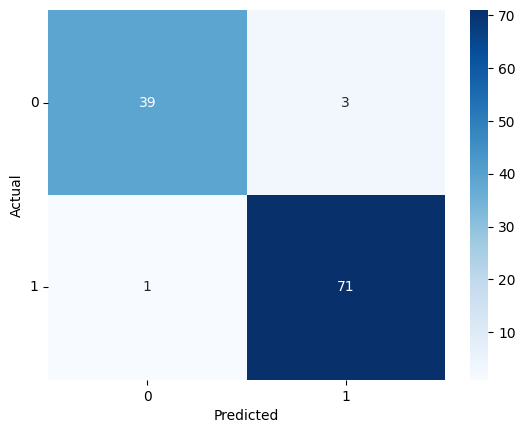

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    pd.DataFrame(cm),
    annot=True,       # liczby w komórkach
    fmt='d',          # format liczb (integer)
    cmap='Blues'
)

plt.yticks(rotation=0)   # etykiety osi Y pionowo
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Macierz pomyłek to narzędzie stosowane w statystyce i analizie danych od lat 60-tych XX wieku, kiedy zaczęto rozwijać modele klasyfikacyjne. Jest podstawowym narzędziem do oceny modeli klasyfikacyjnych, które pozwala na dokładną analizę tego, jak model radzi sobie z poszczególnymi klasami. Dzięki niej można zobaczyć, które przypadki zostały zaklasyfikowane poprawnie, a które błędnie, oraz w jaki sposób model popełnia błędy.

Macierz pomyłek w przypadku klasyfikacji binarnej to tabela o wymiarach 2x2, która przedstawia liczbę przypadków przewidywanych poprawnie i błędnie:

Macierz pokazuje:

* true positive (TP) - w rzeczywistości "positive" i przewidziane jako "positive"
* true negative (TN) - w rzeczywistości "negative" i przewidziane jako "negative"
* false positive (FP) - w rzeczywistości "negative", ale przewidziane jako "positive"
* false negative (FN) - w rzeczywistości "positive", ale przewidziane jako "negative"

|                | Przewidywane Pozytywne | Przewidywane Negatywne |
|----------------|------------------------|-------------------------|
| **Prawdziwe Pozytywne** | TP                     | FN                      |
| **Prawdziwe Negatywne** | FP                     | TN                      |

Macierz pomyłek może też przybrać inną, bardziej skomplikowaną formę, jeżeli nie używamy klasyfikacji binarnej, a wieloklasowej, czyli takiej, która posiada więcej niż 2 klasy:

![komplikowana macierz pomyłek](owoce_3_1_fold.jpg "Skomplikowana macierz pomyłek")

... albo jeszcze bardziej skomplikowana:

![bardzo skomplikowana macierz pomyłek](heatmap_ex.jpg "Bardzo skomplikowana macierz pomyłek")

Macierz pomyłek jest podstawą do obliczania innych miar wydajności modelu, takich jak dokładność, precyzja, czułość i specyficzność.

---

# 11. Precision i recall

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Dokładność (Accuracy)

Dokładność była jedną z pierwszych miar stosowanych do oceny klasyfikatorów. Mierzy ona ogólną skuteczność modelu, jednak może być myląca w przypadku niezbalansowanych zbiorów danych.

$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$

Dokładność mówi, jaki procent wszystkich przypadków model zaklasyfikował poprawnie. Jest używana, gdy klasy są zbalansowane, to znaczy, gdy liczba przypadków pozytywnych i negatywnych jest zbliżona. Dokładność bywa jednak myląca w przypadku niezbalansowanych danych, ponieważ model może mieć wysoką dokładność, mimo że radzi sobie słabo z klasą mniejszościową.

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9649122807017544

### Dokładność zbalansowana

W sytuacji gdy liczba obiektów w obrębie poszczególnych klas decyzyjnych nie jest do siebie zbliżona, warto zastosować miarę dokładności zbalansowanej która odpowiada średniej dokładności dla każdej z klas decyzyjnych w zbiorze danych.

In [11]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy_score(y_test, y_pred)

0.9573412698412699

### Precyzja (Precision)

Precyzja jest szczególnie ważna w dziedzinach takich jak bezpieczeństwo informacji i diagnostyka medyczna, gdzie błędna klasyfikacja pozytywna może być kosztowna.

$
\text{Precision} = \frac{TP}{TP + FP}
$

Precyzja wskazuje, jaki procent przypadków przewidywanych jako pozytywne jest rzeczywiście pozytywny. Jest istotna, gdy koszty błędnych klasyfikacji pozytywnych są wysokie. Na przykład, w filtrowaniu spamu wysoka precyzja minimalizuje liczbę prawdziwych wiadomości oznaczonych jako spam.

In [12]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
precision

0.9594594594594594

### Czułość (Recall) / Sensitivity / TPR (True Positive Rate)

Czułość to miara zorientowana na maksymalizację liczby wykrytych przypadków pozytywnych. Jest szczególnie ważna w medycynie, gdzie niediagnozowanie choroby jest bardzo ryzykowne.

$
\text{Recall} = \frac{TP}{TP + FN}
$

Czułość mierzy skuteczność wykrywania przypadków pozytywnych. Jest istotna, gdy pominięcie przypadku pozytywnego (fałszywie negatywnego) wiąże się z dużymi konsekwencjami, np. w wykrywaniu oszustw lub chorób.

In [13]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
recall

0.9861111111111112

### Specyficzność (Specificity)

Specyficzność jest często używana w parze z czułością, szczególnie w diagnostyce medycznej, aby zobaczyć, jak dobrze model unika błędnych klasyfikacji pozytywnych.

$
\text{Specificity} = \frac{TN}{TN + FP}
$

Specyficzność określa zdolność modelu do wykrywania przypadków negatywnych. Jest ważna, gdy istotne jest unikanie fałszywie pozytywnych wyników. Na przykład, przy wykrywaniu wirusów komputerowych zależy nam na wysokiej specyficzności, aby uniknąć klasyfikowania nieszkodliwych plików jako złośliwych.

In [14]:
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn+fp)
specificity

0.9285714285714286

### F1-Score

F1-score powstał z potrzeby uzyskania jednej miary, która równoważy precyzję i czułość. Stosowany jest w sytuacjach, gdy dane są niezbalansowane.

$
\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$

F1-score jest średnią harmoniczną precyzji i czułości. Jest użyteczny, gdy klasy są niezbalansowane i gdy równie ważne jest minimalizowanie fałszywych pozytywów i fałszywych negatywów. Stosuje się go np. przy analizie danych medycznych, gdzie wykrycie choroby oraz unikanie błędnych diagnoz są równie ważne.

In [15]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
f1

0.9726027397260274

### ROC AUC (Receiver Operating Characteristic - Area Under Curve)

Krzywa ROC została wprowadzona podczas II wojny światowej do oceny wydajności radarów, a następnie adoptowana do analizy modelów statystycznych i uczenia maszynowego.

ROC to wykres, który pokazuje stosunek TPR do FPR (False Positive Rate) przy różnych progach decyzyjnych. Obszar pod krzywą (AUC) pokazuje zdolność modelu do odróżniania klas. 

ROC AUC jest miarą stosowaną, gdy zależy nam na analizie wydajności modelu przy różnych progach decyzyjnych. Przykład zastosowania to diagnostyka medyczna, gdzie lekarz może dostosowywać próg klasyfikacyjny w zależności od ryzyka fałszywych diagnoz.

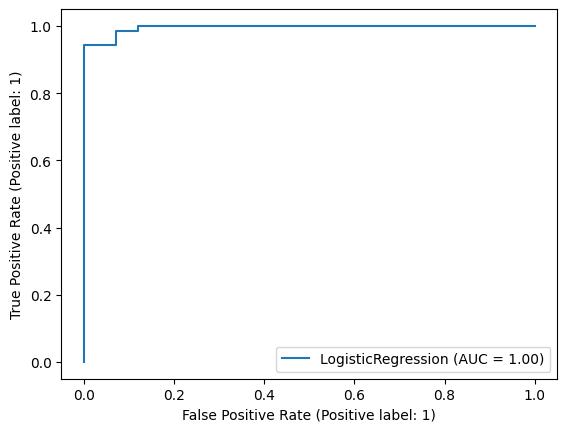

In [16]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

Jeśli **wykres ROC jest prawie prostokątny**, oznacza to, że model klasyfikacyjny działa **bardzo dobrze**.

### Interpretacja prawie prostokątnej krzywej

Jeżeli krzywa:

* szybko idzie **pionowo w górę przy FPR ≈ 0**
* a potem **prawie poziomo przy TPR ≈ 1**

to oznacza że model:

* **dobrze odróżnia klasy**
* osiąga **wysoką czułość przy bardzo małej liczbie fałszywych alarmów**
* ma **AUC bliskie 1**

### W praktyce oznacza to

* model prawie idealnie klasyfikuje obserwacje
* potrafi bardzo dobrze rozdzielać klasy pozytywne i negatywne
* niewielka zmiana progu nie pogarsza znacząco jakości klasyfikacji

### Typowe wartości AUC

| AUC         | Interpretacja                     |
| ----------- | --------------------------------- |
| 0.5         | losowe zgadywanie                 |
| 0.6–0.7     | słaby model                       |
| 0.7–0.8     | umiarkowany                       |
| 0.8–0.9     | dobry                             |
| **0.9–1.0** | **bardzo dobry / prawie idealny** |

### Jednozdaniowa interpretacja (np. do raportu)

> Krzywa ROC ma kształt zbliżony do prostokąta, co wskazuje na bardzo dobrą zdolność modelu do rozróżniania klas. Wysoka wartość AUC oznacza, że model osiąga wysoką czułość przy jednocześnie niskim poziomie fałszywych alarmów.


# 13. Dlaczego metryki są ważne dla XAI

Wyjaśnienia modeli mają sens tylko wtedy, gdy model działa poprawnie.

Jeśli model ma:

* bardzo niski recall
* bardzo niski precision

to wyjaśnianie jego decyzji jest mało wartościowe.

---

# 14. Pipeline

W rzeczywistych projektach ML model nie składa się tylko z algorytmu.

Proces obejmuje również:

* preprocessing
* skalowanie
* selekcję cech

Aby uniknąć błędów, używa się **pipeline**.

---

Pipeline to sekwencja kroków:

```
dane -> preprocessing -> model
```

---

# 15. Pipeline w scikit-learn

Stosowanie potoków transformujących polega na utworzeniu instancji klasy **Pipeline**, której inicjalizator przyjmuje listę zawierającą sprecyzowane kroki przetwarzające dane w postaci krotek: (nazwa, estymator). W znacznej części przypadków wystarczające pozostają klasy (np. *SimpleImputer*) dostarczane przez bibliotekę **Scikit-learn**. Warto mieć na uwadze fakt, że estymator musi być klasą która zawiera metody *fit* oraz *transform*.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [18]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

`StandardScaler` standaryzuje dane, przekształcając je tak, aby miały *średnią* = 0 i *odchylenie standardowe* = 1. Oznacza to, że wartości cech są przeskalowane w oparciu o ich rozkład, bez ustalania minimalnych i maksymalnych wartości.

Standaryzacja to proces polegający na wyśrodkowaniu danych oraz zachowaniu wskazanych parametrów dotyczących rozrzutu wartości: $x' = \frac{x - u}{s}$, gdzie $u$ - średnia arytmetyczna, $s$ - odchylenie standardowe. W bibliotece `Scikit-learn` do standaryzacji służy klasa `StandardScaler` zawarta w module `preprocessing`.

In [19]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=500))])

Jednym z najpopularniejszych podejść do skalowania atrybutów liczbowych jest normalizacja (skalowanie min-madata['MedInc']), które polega na umieszczeniu wszystkich wartości w wyznaczonym zakresie (np. 0-1): $data = \frac{x - min(x)}{max(x) - min(x)}$

W bibliotece `Scikit-learn` do normalizacji służy klasa `MinMaxScaler` zawarta w module `preprocessing`, gdzie można wskazać oczekiwany zakres. Tutaj również zasotosujemy metodę `fit_transform()`.

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled = scaler.fit_transform(X)
pd.DataFrame(scaled)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.042075,-0.954684,0.091977,-0.272534,0.187506,0.584075,0.406279,0.462227,0.372727,0.211036,...,0.241551,-0.716951,0.336620,-0.098604,0.202272,0.238583,0.137220,0.824055,0.196925,-0.162272
1,0.286289,-0.454853,0.231567,0.003181,-0.420240,-0.636464,-0.592784,-0.302485,-0.240404,-0.717355,...,0.213803,-0.392857,0.079635,-0.129571,-0.304893,-0.690873,-0.614058,0.278351,-0.532821,-0.554244
2,0.202991,-0.219479,0.191486,-0.101166,0.028618,-0.137967,-0.074977,0.271372,0.019192,-0.577506,...,0.112771,-0.279851,0.016883,-0.250983,-0.032820,-0.229250,-0.280511,0.670103,-0.192588,-0.573134
3,-0.579819,-0.278323,-0.532997,-0.794189,0.622642,0.622723,0.131209,0.045726,0.552525,1.000000,...,-0.503380,-0.228145,-0.517307,-0.811984,0.830945,0.628023,0.097284,0.769759,1.000000,0.547422
4,0.259785,-0.686845,0.261972,-0.021421,-0.139298,-0.304214,-0.072165,0.036779,-0.243434,-0.626369,...,0.039488,-0.752132,0.013895,-0.316850,-0.125272,-0.655170,-0.361022,0.116838,-0.684999,-0.714810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.379999,-0.142374,0.357335,0.132980,0.053895,-0.407889,0.142924,0.380716,-0.327273,-0.735889,...,0.246531,-0.233475,0.152348,-0.094672,-0.077726,-0.642945,-0.343930,0.523024,-0.804849,-0.788666
565,0.244640,0.253974,0.208071,-0.051962,-0.184436,-0.484571,-0.325211,-0.026740,-0.301010,-0.773799,...,0.121309,0.398188,0.041785,-0.240169,-0.399987,-0.680007,-0.486422,0.118900,-0.602996,-0.851371
566,-0.089498,0.242475,-0.108424,-0.393765,-0.423671,-0.491320,-0.566495,-0.472962,-0.464646,-0.725358,...,-0.213803,0.178038,-0.240102,-0.538537,-0.435647,-0.452591,-0.456390,-0.025430,-0.742559,-0.696183
567,0.289129,0.327021,0.331076,-0.048568,0.176672,0.580394,0.646673,0.510934,0.350505,-0.149115,...,0.267165,0.460554,0.336620,-0.195930,0.239252,0.631516,0.499521,0.821306,-0.005717,-0.095369


Są też atrybuty nienumeryczne (kategorialne):

Kodowanie zmiennych kategorialnych na różne sposoby może znacząco wpływać na skuteczność modeli uczenia maszynowego. Przyjrzyjmy się dwóm popularnym metodom kodowania: **kodowanie etykietowe (Label Encoding)** oraz **One-Hot Encoding**.

### Kodowanie etykietowe (Label Encoding)
W tej metodzie każda kategoria jest mapowana na liczbę całkowitą. Na przykład dla zmiennej "kolor" z wartościami {czerwony, niebieski, zielony} można przypisać:
- czerwony = 0
- niebieski = 1
- zielony = 2

Jest to prosta metoda, ale niesie pewne zagrożenia, szczególnie dla modeli, które traktują zmienne numeryczne jako dane o porządku lub metryce.

**Kiedy działa lepiej:**
- Sprawdza się, gdy zmienna kategorialna rzeczywiście ma jakiś naturalny porządek (np. mały, średni, duży). 
- **Modele drzew decyzyjnych** (jak Random Forest, Gradient Boosting) dobrze sobie radzą z kodowaniem etykietowym, ponieważ są odporne na różnicę w liczbach między kategoriami.

**Główne problemy:**
- W modelach liniowych, sieciach neuronowych, SVM oraz k-nn, model może interpretować różnice liczbowe jako istotne, co może prowadzić do błędnych wniosków. Na przykład, wartość "zielony" = 2 może być traktowana jako dwukrotnie "większa" od wartości "czerwony" = 0, co jest nieprawidłowe, ponieważ kategorie nie mają porządku.

### One-Hot Encoding
W tej metodzie każda kategoria jest reprezentowana jako wektor binarny. Dla przykładu:
- czerwony = [1, 0, 0]
- niebieski = [0, 1, 0]
- zielony = [0, 0, 1]

Każda kategoria jest reprezentowana przez osobną kolumnę, a w odpowiedniej kolumnie jest wartość 1, natomiast w pozostałych kolumnach – 0.

**Kiedy działa lepiej:**
- **Modele liniowe**, sieci neuronowe oraz algorytmy oparte na odległościach, takie jak k-NN i SVM, preferują One-Hot Encoding, ponieważ zmienne binarne eliminują problem nieprawidłowego odczytu różnic liczbowych między kategoriami. Każda kategoria jest traktowana równorzędnie i nie tworzy relacji porządkowych.
- Może lepiej działać, gdy masz do czynienia z dużą liczbą kategorii, które nie są uporządkowane.

**Główne problemy:**
- Zwiększa liczbę cech w danych. Jeśli mamy zmienną z wieloma kategoriami, np. 1000 różnych wartości, One-Hot Encoding może znacząco zwiększyć rozmiar macierzy cech, co prowadzi do większego zużycia pamięci i spowolnienia obliczeń.

### Podsumowanie
1. **Kodowanie etykietowe** jest prostsze i bardziej efektywne dla modeli drzewiastych, które nie mają problemu z interpretacją wartości liczbowych.
2. **One-Hot Encoding** jest bardziej odpowiednie dla modeli liniowych, sieci neuronowych i algorytmów, które wymagają niezależnych, równorzędnych cech.

Wybór odpowiedniej metody kodowania zależy od modelu, którego używasz, oraz charakterystyki danych.

### Scikit-learn

W zbiorach danych często pojawiają się dane tekstowe mające charakter kategorialny. Z uwagi na fakt, że algorytmy uczenia maszynowego operują tylko i wyłącznie na wartościach numerycznych, dane tekstowe wymagają przetworzenia do postaci liczbowej. W takiej sytuacji z pomocą przychodzi klasa `OrdinalEncoder` zawarta w module `preprocessing` biblioteki `Scikit-learn`.

Algorytmy uczące się posiadają zdolność do rozpoznawania wzorców definiowalnych przez liczby. W związku z tym niektóre z nich mogą bardziej istotnie traktować wartość liczbową przypisaną protokołowi UDP niż protokołowi ICMP. W związku z tym warto rozważyć zastosowanie tzw. **kodowanie gorącojedynkowe**, które polega na utworzeniu wektora rzadkiego o rozmiarze *n* (n = liczba różnych wartości tekstowych) z jedną jedynką na pozycji wskazującej daną kategorię. W tym celu należy wykorzystać klasę `OneHotEncoder`.

> Warto by było pomyśleć też o oczyszczaniu danych...

# 16. Dlaczego pipeline jest ważny dla XAI

Metody XAI analizują model **razem z preprocessingiem**.

Jeśli preprocessing nie jest w pipeline, interpretacja może być błędna.

Pipeline zapewnia:

* spójność transformacji
* brak data leakage
* stabilność wyjaśnień

---

# 17. Overfitting i underfitting

Aby ocenić, czy model uczenia maszynowego jest narażony na overfitting (przeuczenie) lub underfitting (niedouczenie), stosuje się analizę wyników modelu na zbiorach treningowym i testowym. Overfitting występuje, gdy model bardzo dobrze dopasowuje się do danych treningowych, ale jego wydajność na danych testowych jest znacznie gorsza, co oznacza, że model nie generalizuje dobrze na nowe dane. Underfitting ma miejsce, gdy model nie radzi sobie dobrze zarówno na zbiorze treningowym, jak i testowym, co sugeruje, że model jest zbyt prosty, aby dobrze reprezentować zależności w danych.

### Krok po kroku: Wykrywanie overfittingu i underfittingu

#### 1. Ocena błędu modelu na zbiorze treningowym i testowym

Typowe podejście do wykrywania overfittingu i underfittingu polega na porównaniu miar wydajności na zbiorze treningowym i testowym. Wysoka dokładność na zbiorze treningowym i niska dokładność na zbiorze testowym sugeruje overfitting, podczas gdy niska dokładność na obu zbiorach oznacza underfitting.

Accuracy = 100% prawie zawsze oznacza overfitting, chyba że masz ekstremalnie prosty problem lub bardzo duży, łatwy zbiór danych.
Ale da się to zbadać i potwierdzić, zamiast tylko zgadywać.

W większości realistycznych problemów uczenia maszynowego uzyskanie 100% trafności na danych testowych oznacza, że:
- model nauczył się na pamięć wzorców (overfitting),
- dane testowe są zbyt łatwe lub mają błędy,
- dane treningowe i testowe nakładają się lub mają duplikaty,
- model jest zbyt skomplikowany jak na wielkość zbioru danych (np. RandomForest 1000 drzew na 200 rekordach).

Dlatego 100% accuracy zwykle powinno zapalać czerwoną lampkę, chyba, że problem jest ekstremalnie prosty i nawet prosty algorytm matematyczny dałby sobie rade.

#### 2. Wykresy krzywych uczenia (Learning Curves)

Krzywe uczenia przedstawiają, jak błąd modelu zmienia się w miarę zwiększania liczby próbek treningowych. Pomagają one lepiej zrozumieć, jak model radzi sobie z różnymi rozmiarami danych i czy jest podatny na overfitting lub underfitting.

### Implementacja w Pythonie: Wykres krzywych uczenia

Poniżej znajduje się przykład, jak użyć scikit-learn do wizualizacji krzywych uczenia dla modelu. Skorzystamy z funkcji `learning_curve`, która pokazuje, jak dokładność modelu zmienia się wraz z rozmiarem danych treningowych.

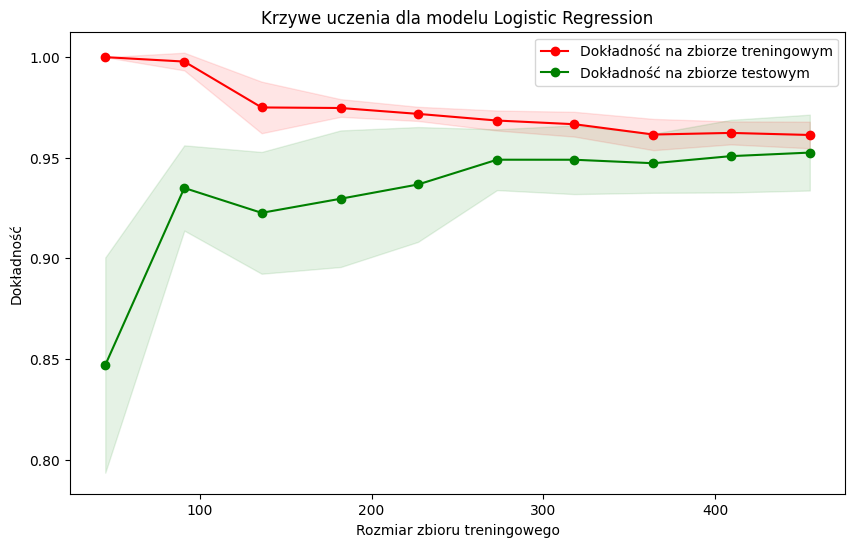

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Ustalanie krzywych uczenia
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='accuracy')

# Obliczenie średnich i odchyleń standardowych
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Wizualizacja wyników
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Dokładność na zbiorze treningowym")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Dokładność na zbiorze testowym")

# Cieniowanie obszarów odchylenia standardowego
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="r", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="g", alpha=0.1)

plt.xlabel("Rozmiar zbioru treningowego")
plt.ylabel("Dokładność")
plt.legend(loc="best")
plt.title("Krzywe uczenia dla modelu Logistic Regression")
plt.show()


### Analiza krzywych uczenia

#### Overfitting
- Krzywa dla zbioru treningowego osiąga wysoką dokładność, ale na zbiorze testowym pozostaje niska.
- Sugeruje to, że model dobrze dopasował się do danych treningowych, ale nie radzi sobie z danymi, których nie widział wcześniej.

#### Underfitting
- Obie krzywe (dla zbioru treningowego i testowego) pozostają stosunkowo nisko i nie zwiększają się znacząco wraz ze wzrostem liczby danych.
- Wskazuje to, że model nie jest wystarczająco skomplikowany, aby uchwycić wzorce w danych, i prawdopodobnie wymaga zwiększenia złożoności.

#### Właściwe dopasowanie
- Krzywe dla zbioru treningowego i testowego są blisko siebie i obie osiągają wysoką wartość przy dużych rozmiarach próbek.
- Wskazuje to, że model generalizuje dobrze i jest odpowiednio dopasowany.

### Inne techniki wykrywania overfittingu i underfittingu

1. **Walidacja krzyżowa**: Podział danych na wiele podzbiorów (foldów) i trenowanie modelu na różnych częściach danych może pomóc w lepszej ocenie jego wydajności. Stabilność wyników na różnych foldach jest oznaką dobrego dopasowania modelu.
  
2. **Regularizacja**: Dodanie regularizacji (np. L1 lub L2 w regresji) może pomóc w uniknięciu overfittingu przez penalizację złożoności modelu.

3. **Early Stopping** (w sieciach neuronowych): Zatrzymywanie treningu, gdy błąd walidacyjny przestaje maleć, może ograniczyć przeuczenie modelu.

# 18. Walidacja krzyżowa

- Pomaga zminimalizować wpływ losowego podziału danych na jakość modelu;
- zbiór danych jest dzielony na kilka części (k-fold), a model jest trenowany i testowany krotnie, z różnymi zestawami danych;
- wyniki są uśredniane, co daje bardziej stabilną ocenę jakości modelu.

Podział train/test zależy od losowania danych.

Dlatego pojedynczy wynik może być przypadkowy.

Rozwiązaniem jest **cross validation**.

---

Idea:

dzielimy dane na kilka części.

Każda część jest kolejno używana jako test.

---

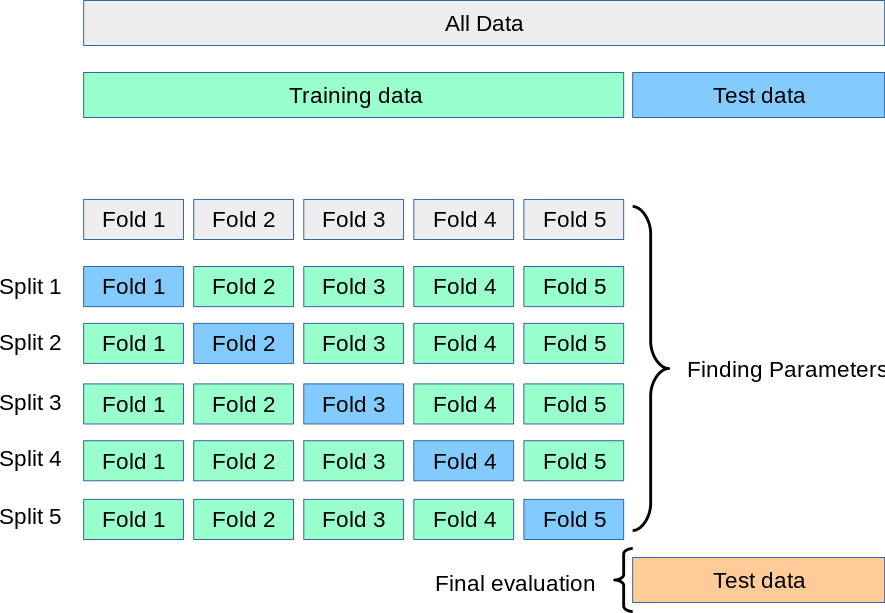

## Czym jest walidacja krzyżowa i po co jej używać?

Walidacja krzyżowa to technika oceny modelu, która wielokrotnie dzieli dane na zbiory treningowe i walidacyjne, trenuje model i sprawdza jego jakość. Główne cele:

* **Rzetelna ocena uogólnienia** modelu (mniej wariancji niż pojedynczy split train/test).
* **Wykrywanie przeuczenia** — jeśli wynik na val jest dużo gorszy niż na train, mamy overfitting.
* **Wybór hiperparametrów** (np. w GridSearchCV) i porównanie wielu modeli.
* **Użycie każdego przykładu do testu** (np. w Leave-One-Out), co jest ważne przy małych zbiorach.

## Główne problemy które rozwiązuje CV

* Niestabilność oceny wynikająca z losowego podziału.
* Zbyt optymistyczne metryki przy jednym, „szczęśliwym” podziale.
* Potrzeba estymacji wariancji wyniku (średnia ± std over folds).

---

## Typy walidacji krzyżowej

### 1. K-Fold CV (`KFold`)

* Dzieli dane na K równych części (foldów). Dla każdej iteracji używa K−1 foldów jako train i 1 fold jako test.
* **Zastosowanie:** uniwersalna metoda; dobry default (np. K=5 lub K=10).
* **Uwaga:** nie zachowuje proporcji klas — użyj stratified dla klasyfikacji.

In [22]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("Accuracy per fold:", scores)
print("Mean accuracy: {:.3f} ± {:.3f}".format(scores.mean(), scores.std()))


Accuracy per fold: [0.95614035 0.96491228 0.93859649 0.97368421 0.92035398]
Mean accuracy: 0.951 ± 0.019


### 2. Stratified K-Fold (`StratifiedKFold`)

* Zachowuje proporcje klas w każdym foldzie.
* **Zastosowanie:** klasyfikacja z nierównymi klasami (imbalanced).

In [23]:
def print_summary(acc_list, bacc_list, name):
    print(f"\n*** PODSUMOWANIE: {name} ***")
    print(f"Średnie Accuracy: {np.mean(acc_list):.4f}  (std={np.std(acc_list):.4f})")
    print(f"Średni Balanced Accuracy : {np.mean(bacc_list):.4f}  (std={np.std(bacc_list):.4f})")

In [24]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_list, bacc_list = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = model.predict(X.iloc[test_idx])

    acc = accuracy_score(y.iloc[test_idx], preds)
    bacc = balanced_accuracy_score(y.iloc[test_idx], preds)
    acc_list.append(acc)
    bacc_list.append(bacc)

    print(f"\nFold {fold}")
    print("Accuracy:", acc, "Balanced accuracy:", bacc)

print_summary(acc_list, bacc_list, "StratifiedKFold")


Fold 0
Accuracy: 0.9649122807017544 Balanced accuracy: 0.971830985915493

Fold 1
Accuracy: 0.9210526315789473 Balanced accuracy: 0.9045201441205373

Fold 2
Accuracy: 0.9649122807017544 Balanced accuracy: 0.9523809523809523

Fold 3
Accuracy: 0.9473684210526315 Balanced accuracy: 0.9484126984126984

Fold 4
Accuracy: 0.9734513274336283 Balanced accuracy: 0.9642857142857143

*** PODSUMOWANIE: StratifiedKFold ***
Średnie Accuracy: 0.9543  (std=0.0187)
Średni Balanced Accuracy : 0.9483  (std=0.0234)


### 3. Leave-One-Out (`LeaveOneOut`, LOO)

* Każdy „fold” to dokładnie jeden przykład jako test, reszta jako train.
* **Zastosowanie:** bardzo małe zbiory (np. <200 próbek).
* **Uwaga:** kosztowny obliczeniowo i bardzo wariancyjny.

In [25]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

preds_all = []
y_all = []

for train_idx, test_idx in loo.split(X):
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict(X.iloc[test_idx])[0]

    preds_all.append(pred)
    y_all.append(y.iloc[test_idx])

acc = accuracy_score(y_all, preds_all)
bacc = balanced_accuracy_score(y_all, preds_all)

print(f"Global LOO Accuracy: {acc}")
print(f"Global LOO Balanced Accuracy : {bacc}")

Global LOO Accuracy: 0.9543057996485061
Global LOO Balanced Accuracy : 0.9482585487024999


# 19. Dlaczego cross validation jest ważne dla XAI

Niektóre modele mogą mieć bardzo niestabilne zachowanie.

Jeśli wyniki cross validation bardzo się różnią, oznacza to że:

* model jest niestabilny
* wyjaśnienia mogą być niestabilne

---

# 20. Porównanie modeli

Teraz porównajmy dwa modele:

* Logistic Regression
* Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rf = Pipeline([
    ("model", RandomForestClassifier())
])

In [28]:
cross_val_score(rf, X, y, cv=5, scoring="roc_auc").mean()

0.991002009039595

# 21. Co to oznacza dla XAI

Logistic Regression:

* łatwo interpretowalna
* prostsza struktura

Random Forest:

* często lepsza skuteczność
* trudniejsza interpretacja

Dlatego potrzebujemy metod takich jak:

* permutation importance
* SHAP
* LIME

---

# Podsumowanie

Na tych zajęciach poznaliśmy podstawowe elementy budowy modeli ML:

* przygotowanie danych
* modele bazowe
* metryki jakości
* pipeline
* walidację krzyżową

Te elementy są kluczowe dla dalszej pracy z metodami XAI, ponieważ pozwalają budować modele, które są stabilne i poprawnie ocenione.